- Entradas: "PwmD", "PwmE", "sPwm", "dPwm"
- Saida: Theta
- Loss = L_d + L_p 


In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from keras import initializers
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib
import os
TITLES = ["Train_1", "Train_2", "Val_1", "Val_2", "Test_1", "Test_2", "LSG_1", "LSG_2"]

PREDICTORS = ["PwmD", "PwmE", "sPwm", "dPwm"]   
TARGET_INT = ["Theta"]  
TARGET = ["DeltaTheta"]
     
INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET)   
     
TIME_STEPS = 15
TS = 0.07
PLOT = True

In [23]:
Datasets = []
for title in TITLES:
    df = pd.read_excel("./../../../00-Data/SavgolDatasets.xlsx", sheet_name=title)
    Datasets.append(df)

In [24]:
for i in range(len(Datasets)):
    Dataset = Datasets[i].copy()

    for var in TARGET_INT:
        Dataset[f"Delta{var}"] = (Dataset[var].shift(-1) - Dataset[var]) / TS
    
    Dataset["sPwm"] = Dataset["PwmD"] + Dataset["PwmE"]
    Dataset["dPwm"] = Dataset["PwmD"] - Dataset["PwmE"]

    Dataset = Dataset.dropna(subset=[f"Delta{var}" for var in TARGET_INT])

    Datasets[i] = Dataset

In [25]:

NormDatasets = []

SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

Train1 = Datasets[0].copy()
Train1[PREDICTORS] = SCALER.fit_transform(Train1[PREDICTORS])
Train1[TARGET] = OUT_SCALER.fit_transform(Train1[TARGET])
NormDatasets.append(Train1)

Train2 = Datasets[1].copy()
Train2[PREDICTORS] = SCALER.transform(Train2[PREDICTORS])
Train2[TARGET] = OUT_SCALER.transform(Train2[TARGET])
NormDatasets.append(Train2)

# concatena
Train = pd.concat([Train1, Train2], ignore_index=True)

for i in range(6):
    CurrentTestDataset = Datasets[i + 2].copy()
    CurrentTestDataset[PREDICTORS] = SCALER.transform(CurrentTestDataset[PREDICTORS])
    CurrentTestDataset[TARGET] = OUT_SCALER.transform(CurrentTestDataset[TARGET])
    NormDatasets.append(CurrentTestDataset)

Val = pd.concat([NormDatasets[2], NormDatasets[3]], ignore_index=True)

In [26]:
os.makedirs("./scalers", exist_ok=True)
os.makedirs("./Data", exist_ok=True)

with pd.ExcelWriter("./Data/NormDatasets.xlsx", engine="openpyxl") as writer_norm:
    for title, normDataset in zip(TITLES, NormDatasets):
        normDataset.to_excel(writer_norm, sheet_name=title[:31], index=False)

with pd.ExcelWriter("./Data/Datasets.xlsx", engine="openpyxl") as writer:
    for title, Dataset in zip(TITLES, Datasets):
        Dataset.to_excel(writer, sheet_name=title[:31], index=False)
        
joblib.dump(SCALER, "./scalers/scaler.pkl")
joblib.dump(OUT_SCALER, "./scalers/out_scaler.pkl")

mean_tf = tf.constant(OUT_SCALER.mean_[0], dtype=tf.float32)
std_tf  = tf.constant(OUT_SCALER.scale_[0], dtype=tf.float32)        

In [27]:
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i-timesteps:i].values)
        Y_seq.append(target_data.iloc[i])
    return np.array(X_seq), np.array(Y_seq)

x_train, y_train = CreateSequences(Train[PREDICTORS], Train[TARGET], TIME_STEPS)

x_val, y_val = CreateSequences((NormDatasets[5])[PREDICTORS], (NormDatasets[5])[TARGET], TIME_STEPS)
print(f"Dimensão da entrada: {np.shape(x_train)}")
print(f"Dimensão da saida: {np.shape(y_train)}")

print(f"Dimensão da entrada: {np.shape(x_val)}")
print(f"Dimensão da saida: {np.shape(y_val)}")

Dimensão da entrada: (1935, 15, 4)
Dimensão da saida: (1935, 1)
Dimensão da entrada: (1255, 15, 4)
Dimensão da saida: (1255, 1)


In [28]:
Wd_train =  Train["Wd"].values[:len(x_train)]
We_train =  Train["We"].values[:len(x_train)]
theta_train = Train["Theta"].values[:len(x_train)]

print(f"Dimensão da entrada: {np.shape(x_train)}")
print(f"Dimensão da saida: {np.shape(y_train)}")

print(f"Dimensão da entrada fisica : {np.shape(Wd_train)}")
print(f"Dimensão da entrada fisica: {np.shape(We_train)}")

Dimensão da entrada: (1935, 15, 4)
Dimensão da saida: (1935, 1)
Dimensão da entrada fisica : (1935,)
Dimensão da entrada fisica: (1935,)


$$ \dot{\theta} = \frac{R}{2L} (\phi_d - \phi_e) $$
$$ \dot{x} = \frac{R}{2} (\phi_d + \phi_e) (\cos(\theta))$$
$$ \dot{y} = \frac{R}{2} (\phi_d + \phi_e) (\sin(\theta)) $$

In [29]:
R = tf.constant(0.0328, dtype=tf.float32)
L = tf.constant(0.0615, dtype=tf.float32)
dt = tf.constant(TS, dtype=tf.float32)

def CinematicModel(Wd, We, theta):

    dtheta_cin = (R / (2 * L)) * (Wd - We)
    return [dtheta_cin]
    

In [30]:

def NumericalIntegration(dataset, dq):

    q = [None] * OUTPUT_SIZE

    init_vals = np.array([
        dataset[name].iloc[0] for name in TARGET_INT
    ])

    for j in range(OUTPUT_SIZE):
        q[j] = init_vals[j] + np.cumsum(dq[j] * TS)

    return q

def GetCin(dataset): 
    dq = CinematicModel(tf.convert_to_tensor(dataset["Wd"].values, dtype=tf.float32),
                        tf.convert_to_tensor(dataset["We"].values, dtype=tf.float32), 
                        tf.convert_to_tensor(dataset["Theta"].values, dtype=tf.float32))
    q = NumericalIntegration(dataset, dq)
    return np.vstack(q).T, np.vstack(dq).T

In [104]:
def BuildRNN(architecture, initializer, regularizer):

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)))

    for i, units in enumerate(architecture):

        return_sequences = (i < len(architecture) - 1)
        if return_sequences == True:
            act = 'linear'
        else:
            act = 'tanh'
        model.add(
            tf.keras.layers.SimpleRNN(
                units,
                activation=act,
                return_sequences=return_sequences,
                kernel_initializer=initializer,
                kernel_regularizer=regularizer,
                recurrent_regularizer=regularizer,
                bias_regularizer=regularizer
            )
        )

    model.add(
        tf.keras.layers.Dense(
            OUTPUT_SIZE,
            activation="linear",
            kernel_initializer=initializer,
            kernel_regularizer=regularizer,
            bias_regularizer=regularizer
        )
    )

    return model

In [105]:
@tf.function
def train_step(model, optimizer, x, dy, Wd, We, theta0, Ld, Lp):
    alpha = 5
    weights = 1 + alpha * tf.abs(dy)

    with tf.GradientTape() as tape:

        dy_pred = model(x, training=True)
        
        # loss dos dados
        data_loss = tf.reduce_mean(weights * tf.square(dy_pred - dy))
        
        # termo físico
        physics = tf.stack(CinematicModel(Wd, We, theta0), axis=1)   
             
        # normalização correta
        physics_norm = (physics - mean_tf) / std_tf

        physics_loss = tf.reduce_mean(tf.square(dy_pred - physics_norm))

        loss = Ld * data_loss +  Lp * physics_loss 

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return loss

In [106]:
Wd_train = tf.convert_to_tensor(Wd_train, dtype=tf.float32)
We_train = tf.convert_to_tensor(We_train, dtype=tf.float32)
theta_train = tf.convert_to_tensor(theta_train, dtype=tf.float32)

x_train_tf = tf.convert_to_tensor(x_train, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)

x_val_tf = tf.convert_to_tensor(x_val, dtype=tf.float32)
y_val_tf = tf.convert_to_tensor(y_val, dtype=tf.float32)

In [107]:
def EarlyStopping(model, best_loss, counter, best_weights, min_delta=1e-3):
    val_pred = model(x_val_tf, training=False)
    val_loss = tf.reduce_mean(tf.square(val_pred - y_val_tf))
    
    if val_loss < (best_loss - min_delta):
        best_loss = val_loss
        counter = 0
        best_weights = model.get_weights()

    else:
        counter += 1

    return best_loss, counter, best_weights, val_loss

def TrainPINN(model, optimizer, Ld, Lp, patience=200, best_loss=np.inf):
    counter = 0
    best_weights = model.get_weights()

    for epoch in range(20000):

        loss = train_step(model, optimizer, x_train_tf, y_train_tf,
                          Wd_train, We_train, theta_train, Ld, Lp)
        
        best_loss, counter, best_weights, val_loss =  EarlyStopping(model, best_loss, counter, best_weights)
        
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            model.set_weights(best_weights)
            break

        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Train Loss {loss.numpy():.6f} | Val Loss {val_loss.numpy():.6f}")

In [108]:
def PlotOut(ax, title, target_name, y_true, y_pred, y_cin):
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    ax.plot(time, y_true, linestyle='-', linewidth=1.5, color='tab:blue', label='Amostras Reais')
    ax.plot(time, y_pred, linestyle='--', linewidth=1.5, color='tab:orange', label='Valores preditos')
    ax.plot(time, y_cin, linestyle=':', linewidth=2, color='tab:green', label='Modelo Cinemático')

    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)
    ax.legend()
    ax.grid(True)


def EvalModel(model):
    n_targets = len(TARGET)
    if PLOT == True:
        n_datasets = len(Datasets)
        fig, axs = plt.subplots(
                n_datasets,
                2 * n_targets,
                figsize=(6 * 2 * n_targets, 4 * n_datasets)
            )
    

    # estrutura das métricas
    metrics = {
        name: {
            "R2_Train_1": [], "R2_Train_2": [],
            "R2_Val_1": [], "R2_Val_2": [],
            "R2_Test_1": [], "R2_Test_2": [], 
            "R2_LSG_1": [], "R2_LSG_2": [],
            "MSE_Train_1": [], "MSE_Train_2": [],
            "MSE_Val_1": [], "MSE_Val_2": [],
            "MSE_Test_1": [], "MSE_Test_2": [], 
            "MSE_LSG_1": [], "MSE_LSG_2": [],

        }
        for name in TARGET_INT
    }

    for i, NormDataset in enumerate(NormDatasets):
        x = NormDataset[PREDICTORS]
        y = Datasets[i][TARGET_INT]
        dy = Datasets[i][TARGET]

        x, y = CreateSequences(x, y, TIME_STEPS)

        # predição (dy normalizado)
        dy_pred = model(tf.convert_to_tensor(x, dtype=tf.float32)).numpy()

        # desnormalizar
        dy_pred = OUT_SCALER.inverse_transform(dy_pred)

        # cinemático
        y_cin, dy_cin = GetCin(Datasets[i])

        # alinhar tamanhos
        y_true = y
        dy_true = dy.iloc[TIME_STEPS:].values

        y_cin = y_cin[:y_true.shape[0]]
        dy_cin = dy_cin[:dy_true.shape[0]]

        # reconstrução de y
        y_pred = np.zeros_like(dy_pred)

        init_vals = np.array([
            Datasets[i][name].iloc[0] for name in TARGET_INT
        ])

        for j in range(n_targets):
            y_pred[:, j] = init_vals[j] + np.cumsum(dy_pred[:, j] * TS)


        # cálculo das métricas
        for j, name in enumerate(TARGET_INT):

            r2 = r2_score(y_true[:, j], y_pred[:, j])
            mse = mean_squared_error(y_true[:, j], y_pred[:, j])

            metrics[name][f"R2_{TITLES[i]}"].append(r2)
            metrics[name][f"MSE_{TITLES[i]}"].append(mse)

            print(f"{name} | {TITLES[i]} -> " f"R² = {r2:.4f}, MSE = {mse:.4e}")

            if PLOT == True:
                # 🔹 coluna da posição (y)
                ax_y = axs[i, j] if n_datasets > 1 else axs[j]
                PlotOut(
                    ax_y,
                    TITLES[i],
                    f"{name}",
                    y_true[:, j],
                    y_pred[:, j],
                    y_cin[:, j]
                )

                # 🔹 coluna da derivada (dy)
                ax_dy = axs[i, j + n_targets] if n_datasets > 1 else axs[j + n_targets]
                PlotOut(
                    ax_dy,
                    TITLES[i],
                    f"d{name}",
                    dy_true[:, j],
                    dy_pred[:, j],
                    dy_cin[:, j]
                )
    if PLOT == True:
        plt.tight_layout()

    return metrics

In [109]:
def to_scalar(x):
    return float(x[0]) if isinstance(x, list) else float(x)

In [110]:
def UpdateRow(metrics, arch, Ld, Lp, r, seed, excel_file):

    model_name = f"model_arch{'-'.join(map(str, arch))}_r{r}_Ld{Ld}_Lp{Lp}_seed{seed}"

    row = {
        "model": model_name,
        "Neurons": arch,
        "Ld": Ld,
        "Lp": Lp,
        "reg": r,
        "seed": seed,
    }

    for name in TARGET_INT:
        row.update({
            f"R2_Train_1_{name}": to_scalar(metrics[name]["R2_Train_1"]),
            f"MSE_Train_1_{name}": to_scalar(metrics[name]["MSE_Train_1"]),
            f"R2_Train_2_{name}": to_scalar(metrics[name]["R2_Train_2"]),
            f"MSE_Train_2_{name}": to_scalar(metrics[name]["MSE_Train_2"]),
            f"R2_Val_1_{name}": to_scalar(metrics[name]["R2_Val_1"]),
            f"MSE_Val_1_{name}": to_scalar(metrics[name]["MSE_Val_1"]),
            f"R2_Val_2_{name}": to_scalar(metrics[name]["R2_Val_2"]),
            f"MSE_Val_2_{name}": to_scalar(metrics[name]["MSE_Val_2"]),
            f"R2_Test_1_{name}": to_scalar(metrics[name]["R2_Test_1"]),
            f"MSE_Test_1_{name}": to_scalar(metrics[name]["MSE_Test_1"]),
            f"R2_Test_2_{name}": to_scalar(metrics[name]["R2_Test_2"]),
            f"MSE_Test_2_{name}": to_scalar(metrics[name]["MSE_Test_2"]),
            f"R2_LSG_1_{name}": to_scalar(metrics[name]["R2_LSG_1"]),
            f"MSE_LSG_1_{name}": to_scalar(metrics[name]["MSE_LSG_1"]),
            f"R2_LSG_2_{name}": to_scalar(metrics[name]["R2_LSG_2"]),
            f"MSE_LSG_2_{name}": to_scalar(metrics[name]["MSE_LSG_2"]),
        })

    df = pd.DataFrame([row])

    try:
        old = pd.read_excel(excel_file)
        new_df = pd.concat([old, df], ignore_index=True)
        new_df.to_excel(excel_file, index=False)
    except FileNotFoundError:
        df.to_excel(excel_file, index=False)

    print(f"Modelo {arch} | Ld={Ld} Lp={Lp} r={r} seed={seed} salvo.")


In [111]:
def ExportModel(model, model_name):

    os.makedirs("weights", exist_ok=True)
    os.makedirs("models", exist_ok=True)

    weights_path = f"weights/{model_name}.weights.h5"
    model_path = f"models/{model_name}.keras"

    model.save_weights(weights_path)
    model.save(model_path)

    print(f"Modelo salvo em:\n{model_path}\n{weights_path}")

Epoch 0 | Train Loss 9.485463 | Val Loss 1.654878
Epoch 100 | Train Loss 6.603799 | Val Loss 1.279118
Epoch 200 | Train Loss 5.082760 | Val Loss 0.859161
Epoch 300 | Train Loss 3.972366 | Val Loss 0.813191
Epoch 400 | Train Loss 3.089379 | Val Loss 0.643947
Epoch 500 | Train Loss 2.526422 | Val Loss 0.649962
Epoch 600 | Train Loss 2.150011 | Val Loss 0.690412
Early stopping at epoch 629
Modelo salvo em:
models/model_arch16-8-4_r0.01_Ld0.5_Lp0.5_seed600.keras
weights/model_arch16-8-4_r0.01_Ld0.5_Lp0.5_seed600.weights.h5
Theta | Train_1 -> R² = 0.6997, MSE = 6.8109e-02
Theta | Train_2 -> R² = 0.7630, MSE = 5.2115e-02
Theta | Val_1 -> R² = 0.7695, MSE = 5.2881e-02
Theta | Val_2 -> R² = 0.7106, MSE = 6.6291e-02
Theta | Test_1 -> R² = 0.3686, MSE = 2.0727e-01
Theta | Test_2 -> R² = -0.1464, MSE = 3.7398e-01
Theta | LSG_1 -> R² = 0.7617, MSE = 9.4039e-02
Theta | LSG_2 -> R² = 0.3005, MSE = 2.2699e-01
Modelo [16, 8, 4] | Ld=0.5 Lp=0.5 r=0.01 seed=600 salvo.


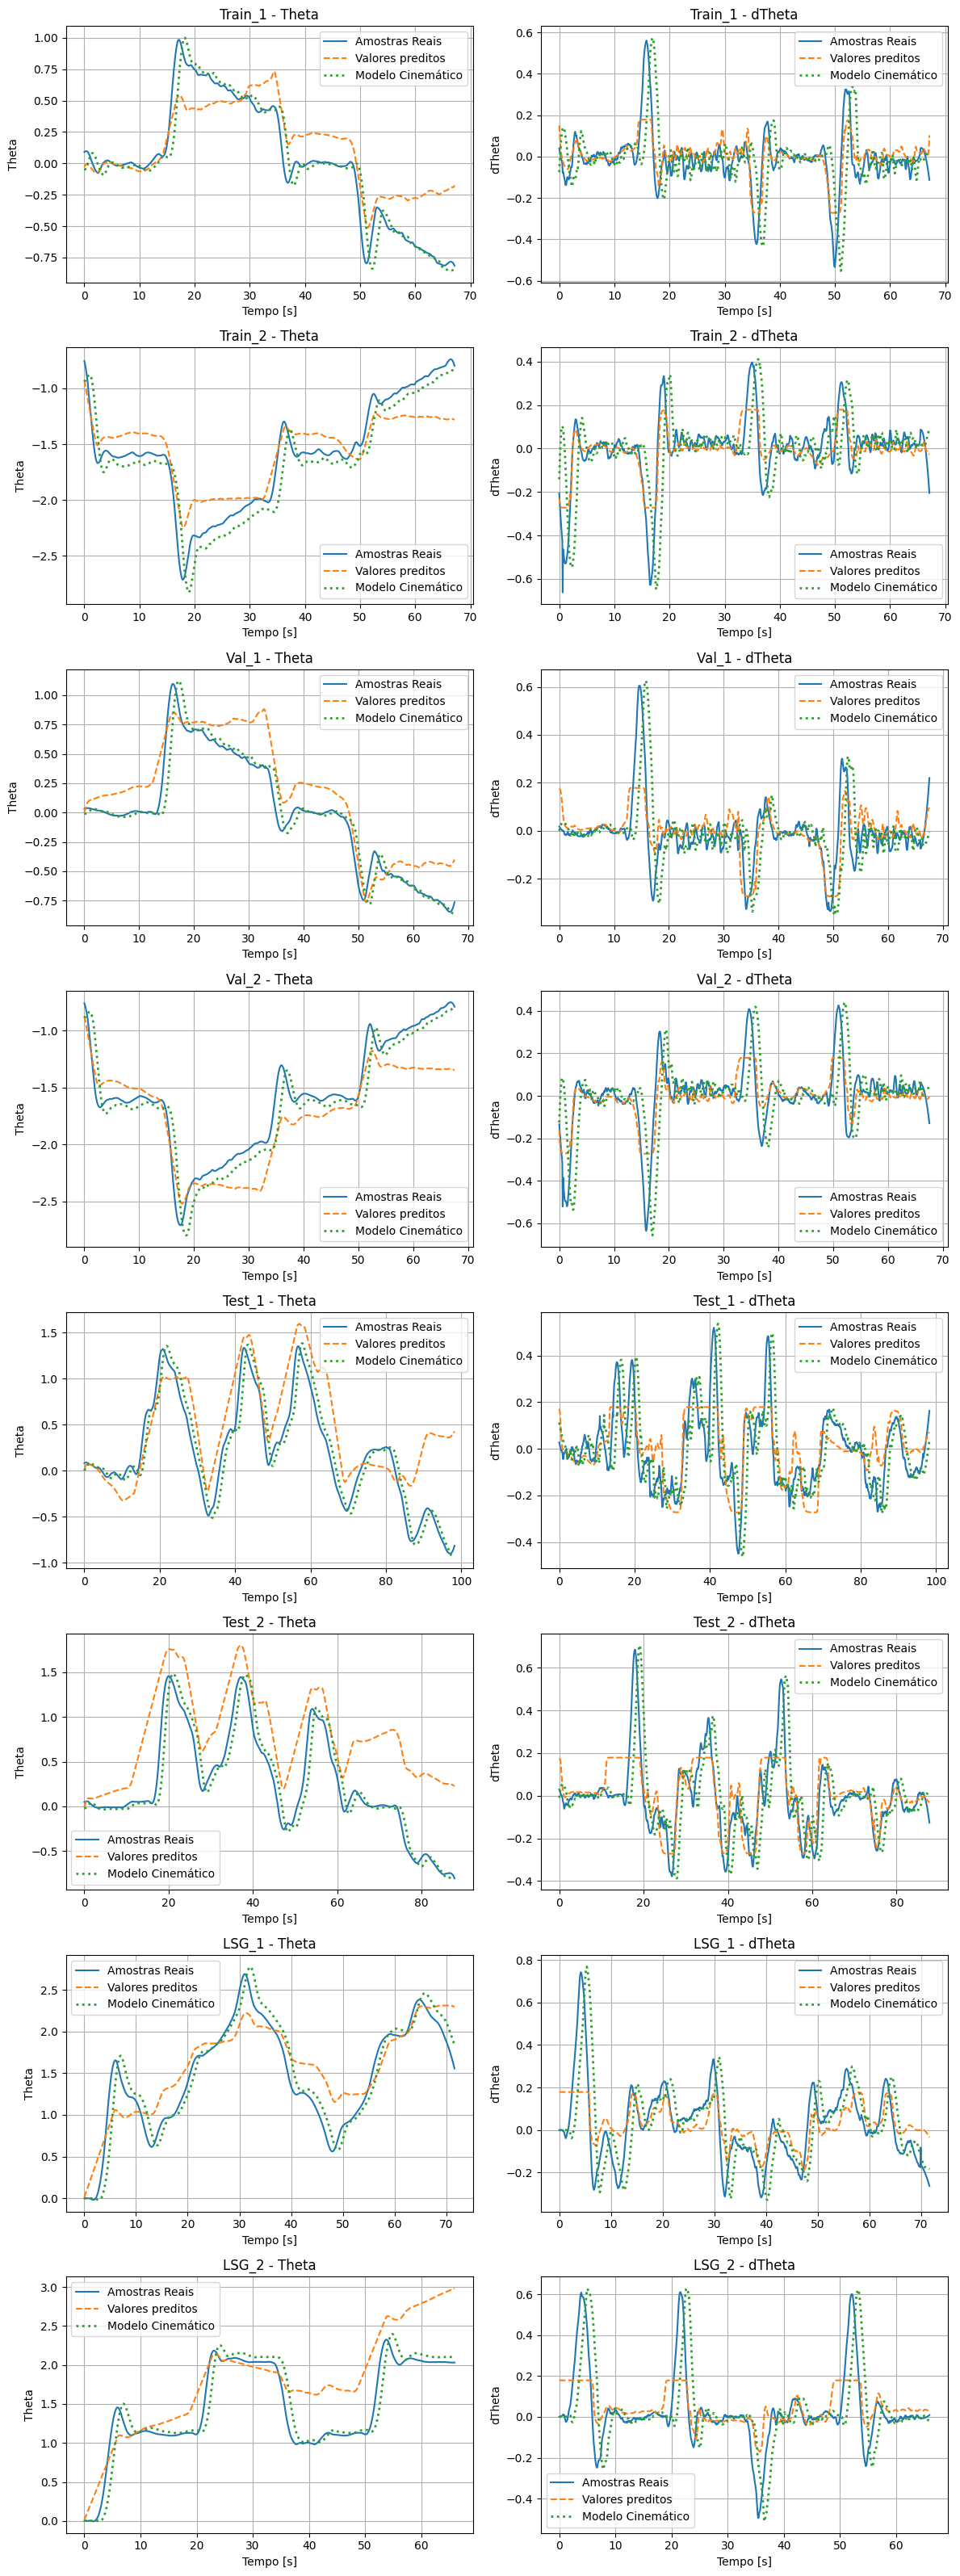

In [112]:
from tensorflow.keras.optimizers import Adam
from itertools import product

N_MODELS = 5
seeds = np.random.choice(range(1, 10000), size=N_MODELS, replace=False)

architectures = [[16, 8, 4],
    [32], [64], [128], [264],
    [8, 4], [16, 8], [32, 16], [64, 32], [128, 64], [264, 128],
    [16, 8, 4], [32, 16, 8], [128, 64, 32], [264, 128, 64]
]

Ld_Lp = [[0.5, 0.5], [0.3,0.7], [0.7,0.3]]
r_values = [0.01, 0.9]

results = {}
# produto cartesiano de todos hiperparâmetros
for arch, (Ld, Lp), r in product(architectures, Ld_Lp, r_values):

    for i, s in enumerate(seeds):

        tf.keras.backend.clear_session()

        init = initializers.RandomNormal(seed=int(s))
        reg = tf.keras.regularizers.l2(r)
        model = BuildRNN(arch, init, reg)
        model.build((None, TIME_STEPS, INPUT_SIZE))

        opt = Adam(learning_rate=0.001)
        opt.build(model.trainable_variables)

        TrainPINN(
            model,
            Ld=Ld,
            Lp=Lp,
            optimizer=opt
        )
        model_name = f"model_arch{'-'.join(map(str, arch))}_r{r}_Ld{Ld}_Lp{Lp}_seed{s}"
        ExportModel(model, model_name=model_name)
        metrics = EvalModel(model)
        UpdateRow(metrics, arch, Ld, Lp, r, s, excel_file="resultados.xlsx")
        break
    break